In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

DATA_DIR = os.path.join('..', 'data')

def load(name):
    return pd.read_csv(os.path.join(DATA_DIR, f'{name}.csv'))

customers   = load('olist_customers_dataset')
geolocation = load('olist_geolocation_dataset')
order_items = load('olist_order_items_dataset')
payments    = load('olist_order_payments_dataset')
reviews     = load('olist_order_reviews_dataset')
orders      = load('olist_orders_dataset')
products    = load('olist_products_dataset')
sellers     = load('olist_sellers_dataset')

print('✓ Todas as tabelas carregadas')

✓ Todas as tabelas carregadas


In [10]:
# Count how many unique zip code prefixes exist
unique_zipcodes = geolocation['geolocation_zip_code_prefix'].nunique()

print(f'Unique ZIP code prefixes: {unique_zipcodes}\n'
      f'Total records: {len(geolocation)}')

# Count repetitions of each ZIP code prefix
zipcode_counts = (
    geolocation['geolocation_zip_code_prefix']
    .value_counts()
    .reset_index()
)

zipcode_counts.columns = ['geolocation_zip_code_prefix', 'count']

# Show the table
zipcode_counts.head(10)

Unique ZIP code prefixes: 19015
Total records: 1000163


,geolocation_zip_code_prefix,count
0,24220,1146
1,24230,1102
2,38400,965
3,35500,907
4,11680,879
5,22631,832
6,30140,810
7,11740,788
8,38408,773
9,28970,743


In [11]:
geolocation['geolocation_zip_code_prefix'] = (
    geolocation['geolocation_zip_code_prefix']
    .astype(str)
    .str.zfill(5)
)

# Check how many unique values each ZIP prefix has in the other columns
zip_analysis = (
    geolocation
    .groupby('geolocation_zip_code_prefix')
    .agg({
        'geolocation_lat': 'nunique',
        'geolocation_lng': 'nunique',
        'geolocation_city': 'nunique',
        'geolocation_state': 'nunique'
    })
    .reset_index()
)

# Show ZIP prefixes where something changes
different_values = zip_analysis[
    (zip_analysis['geolocation_lat'] > 1) |
    (zip_analysis['geolocation_lng'] > 1) |
    (zip_analysis['geolocation_city'] > 1) |
    (zip_analysis['geolocation_state'] > 1)
]

print(f'ZIP prefixes with differing values: {len(different_values)}')

different_values.head(10)

ZIP prefixes with differing values: 17823


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,01001,10,10,2,1
1,01002,6,6,2,1
2,01003,10,10,2,1
3,01004,14,14,2,1
4,01005,11,11,2,1
5,01006,7,7,2,1
6,01007,15,15,2,1
7,01008,12,12,2,1
8,01009,7,7,2,1
9,01010,5,5,2,1


In [12]:
geolocation['geolocation_zip_code_prefix'] = (
    geolocation['geolocation_zip_code_prefix']
    .astype(str)
    .str.zfill(5)
)

geo_unique = (
    geolocation
    .groupby('geolocation_zip_code_prefix')
    .agg({
        'geolocation_lat': 'mean',
        'geolocation_lng': 'mean',
        'geolocation_city': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
        'geolocation_state': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
    })
    .reset_index()
)

# Show result
print(f'Original rows: {len(geolocation)}')
print(f'Unique ZIP prefixes: {len(geo_unique)}')

geo_unique.head()

Original rows: 1000163
Unique ZIP prefixes: 19015


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,01001,-23.550190,-46.634024,sao paulo,SP
1,01002,-23.548146,-46.634979,sao paulo,SP
2,01003,-23.548994,-46.635731,sao paulo,SP
3,01004,-23.549799,-46.634757,sao paulo,SP
4,01005,-23.549456,-46.636733,sao paulo,SP


In [13]:
# Customers
customers['customer_zip_code_prefix'] = (
    customers['customer_zip_code_prefix']
    .astype(str)
    .str.zfill(5)
)

# Sellers
sellers['seller_zip_code_prefix'] = (
    sellers['seller_zip_code_prefix']
    .astype(str)
    .str.zfill(5)
)

# Geo table
geo_unique['geolocation_zip_code_prefix'] = (
    geo_unique['geolocation_zip_code_prefix']
    .astype(str)
    .str.zfill(5)
)

In [14]:
customer_geo = geo_unique.rename(columns={
    'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
    'geolocation_lat': 'customer_lat',
    'geolocation_lng': 'customer_lng'
})[['customer_zip_code_prefix', 'customer_lat', 'customer_lng']]

In [16]:
seller_geo = geo_unique.rename(columns={
    'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
    'geolocation_lat': 'seller_lat',
    'geolocation_lng': 'seller_lng'
})[['seller_zip_code_prefix', 'seller_lat', 'seller_lng']]

In [17]:
# Orders + customers
df = orders.merge(
    customers[['customer_id', 'customer_zip_code_prefix']],
    on='customer_id',
    how='left'
)

# Add items (seller info)
df = df.merge(
    order_items[['order_id', 'seller_id']],
    on='order_id',
    how='left'
)

# Add seller ZIP
df = df.merge(
    sellers[['seller_id', 'seller_zip_code_prefix']],
    on='seller_id',
    how='left'
)

# Add customer coordinates
df = df.merge(
    customer_geo,
    on='customer_zip_code_prefix',
    how='left'
)

# Add seller coordinates
df = df.merge(
    seller_geo,
    on='seller_zip_code_prefix',
    how='left'
)

In [18]:
# Convert dates
df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date']
)

df['order_delivered_carrier_date'] = pd.to_datetime(
    df['order_delivered_carrier_date']
)

# Delivery time in days
df['delivery_time_days'] = (
    df['order_delivered_customer_date'] -
    df['order_delivered_carrier_date']
).dt.days

In [19]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan

    R = 6371  # Earth radius in km

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = (
        sin(dlat / 2) ** 2 +
        cos(radians(lat1)) *
        cos(radians(lat2)) *
        sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [20]:
df['distance_km'] = df.apply(
    lambda row: haversine(
        row['seller_lat'],
        row['seller_lng'],
        row['customer_lat'],
        row['customer_lng']
    ),
    axis=1
)

In [21]:
df[[
    'order_id',
    'seller_id',
    'customer_zip_code_prefix',
    'seller_zip_code_prefix',
    'distance_km',
    'delivery_time_days'
]].head()

,order_id,seller_id,customer_zip_code_prefix,seller_zip_code_prefix,distance_km,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,03149,09350,18.576110,6.0
1,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,47813,31570,851.495069,12.0
2,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,75265,14840,514.410666,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,59296,31842,1822.226336,9.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,09195,08752,29.676625,1.0


In [24]:
output_path = os.path.join('..', 'data', 'gold', 'gold_delivery_details.csv')

df.to_csv(output_path, index=False)

print(f'✓ File saved at: {output_path}')

✓ File saved at: ../data/gold/gold_delivery_details.csv


In [25]:
# Correlation between distance and delivery time
correlation = df['distance_km'].corr(df['delivery_time_days'])

print(f'Correlation: {correlation:.4f}')

Correlation: 0.4227


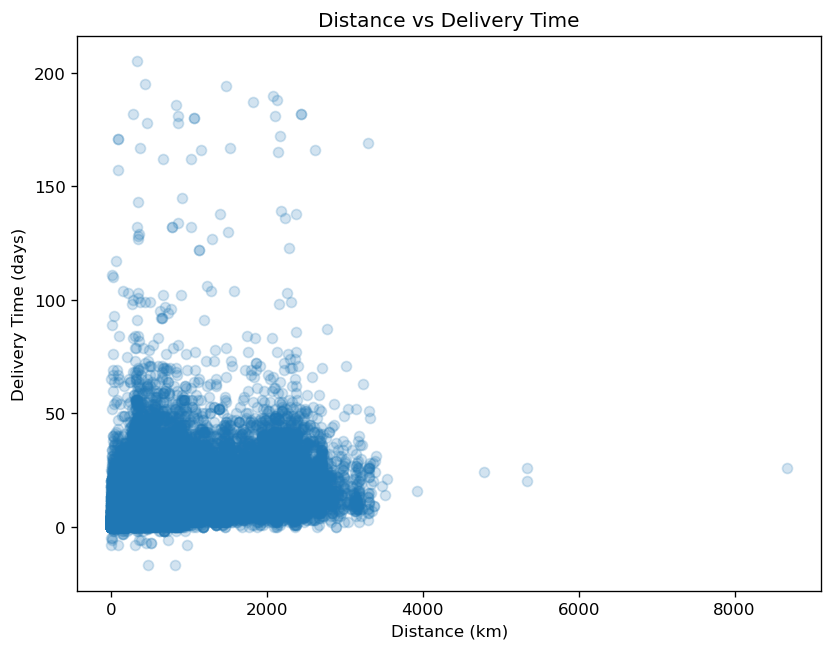

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['distance_km'],
    df['delivery_time_days'],
    alpha=0.2
)

plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (days)')
plt.title('Distance vs Delivery Time')

plt.show()

In [27]:
filtered_df = df[
    (df['distance_km'] < 3000) &
    (df['delivery_time_days'] < 60)
]

correlation = filtered_df['distance_km'].corr(
    filtered_df['delivery_time_days']
)

print(f'Filtered Correlation: {correlation:.4f}')

Filtered Correlation: 0.4667


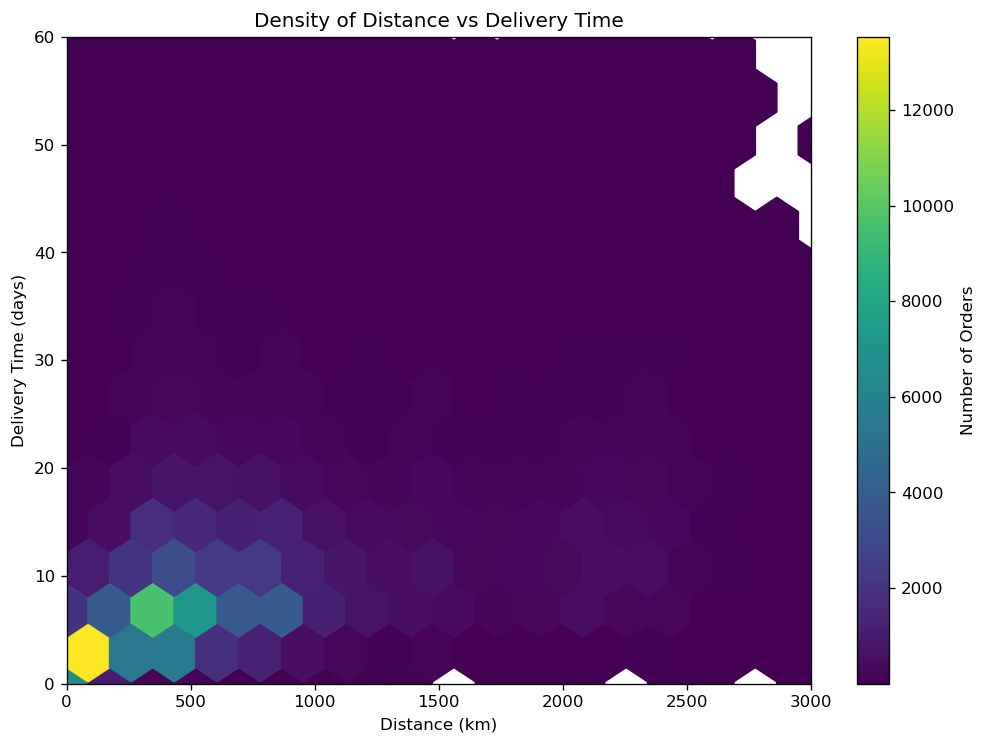

In [28]:
plot_df = df[
    (df['distance_km'] < 3000) &
    (df['delivery_time_days'] < 60)
]
plt.figure(figsize=(10, 7))

hb = plt.hexbin(
    df['distance_km'],
    df['delivery_time_days'],
    gridsize=50,
    cmap='viridis',
    mincnt=1
)

plt.colorbar(hb, label='Number of Orders')

plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (days)')
plt.title('Density of Distance vs Delivery Time')

plt.xlim(0, 3000)
plt.ylim(0, 60)

plt.show()

In [29]:
# Count sales per seller/product
seller_product_counts = (
    order_items
    .groupby(['seller_id', 'product_id'])
    .size()
    .reset_index(name='times_sold')
)

# Get the most sold product for each seller
top_products = (
    seller_product_counts
    .sort_values(['seller_id', 'times_sold'], ascending=[True, False])
    .drop_duplicates(subset='seller_id')
)

# Rename column
gold_sellers_details = top_products.rename(columns={
    'product_id': 'specialized_product'
})[['seller_id', 'specialized_product', 'times_sold']]

# Show result
gold_sellers_details.head()

,seller_id,specialized_product,times_sold
0,0015a82c2db000af6aaaf3ae2ecb0532,a2ff5a97bf95719e38ea2e3b4105bce8,3
1,001cca7ae9ae17fb1caed9dfb1094831,08574b074924071f4e201e151b152b4e,113
12,001e6ad469a905060d959994f1b41e4f,093cd981b714bcdff182b427d87fc8fc,1
14,002100f778ceb8431b7a1020ff7ab48f,158102fe543dbaeb84d87811bfe06d0d,17
37,003554e2dce176b5555353e4f3555ac8,67f36b3689147d882d2b298fd0715d80,1


In [30]:
# Create seller-review relation
seller_reviews = (
    order_items[['order_id', 'seller_id']]
    .merge(
        reviews[['order_id', 'review_score']],
        on='order_id',
        how='left'
    )
)

# Average review score per seller
seller_avg_reviews = (
    seller_reviews
    .groupby('seller_id')['review_score']
    .mean()
    .reset_index()
)

# Rename column
seller_avg_reviews = seller_avg_reviews.rename(columns={
    'review_score': 'average_review_score'
})

seller_avg_reviews.head()

,seller_id,average_review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542
2,001e6ad469a905060d959994f1b41e4f,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,3.982143
4,003554e2dce176b5555353e4f3555ac8,5.000000


In [31]:
gold_sellers_details = gold_sellers_details.merge(
    seller_avg_reviews,
    on='seller_id',
    how='left'
)

gold_sellers_details.head()

,seller_id,specialized_product,times_sold,average_review_score
0,0015a82c2db000af6aaaf3ae2ecb0532,a2ff5a97bf95719e38ea2e3b4105bce8,3,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,08574b074924071f4e201e151b152b4e,113,3.902542
2,001e6ad469a905060d959994f1b41e4f,093cd981b714bcdff182b427d87fc8fc,1,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,158102fe543dbaeb84d87811bfe06d0d,17,3.982143
4,003554e2dce176b5555353e4f3555ac8,67f36b3689147d882d2b298fd0715d80,1,5.000000


In [32]:
# Merge order items with product categories
seller_categories = (
    order_items[['seller_id', 'product_id']]
    .merge(
        products[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )
)

# Count how many times each seller sold each category
seller_category_counts = (
    seller_categories
    .groupby(['seller_id', 'product_category_name'])
    .size()
    .reset_index(name='category_sales')
)

# Get the most sold category per seller
top_categories = (
    seller_category_counts
    .sort_values(
        ['seller_id', 'category_sales'],
        ascending=[True, False]
    )
    .drop_duplicates(subset='seller_id')
)

# Keep only needed columns
top_categories = top_categories.rename(columns={
    'product_category_name': 'specialized_category'
})[['seller_id', 'specialized_category']]

top_categories.head()

,seller_id,specialized_category
0,0015a82c2db000af6aaaf3ae2ecb0532,eletroportateis
2,001cca7ae9ae17fb1caed9dfb1094831,ferramentas_jardim
3,001e6ad469a905060d959994f1b41e4f,esporte_lazer
4,002100f778ceb8431b7a1020ff7ab48f,moveis_decoracao
5,004c9cd9d87a3c30c522c48c4fc07416,cama_mesa_banho


In [33]:
gold_sellers_details = gold_sellers_details.merge(
    top_categories,
    on='seller_id',
    how='left'
)

gold_sellers_details.head()

,seller_id,specialized_product,times_sold,average_review_score,specialized_category
0,0015a82c2db000af6aaaf3ae2ecb0532,a2ff5a97bf95719e38ea2e3b4105bce8,3,3.666667,eletroportateis
1,001cca7ae9ae17fb1caed9dfb1094831,08574b074924071f4e201e151b152b4e,113,3.902542,ferramentas_jardim
2,001e6ad469a905060d959994f1b41e4f,093cd981b714bcdff182b427d87fc8fc,1,1.000000,esporte_lazer
3,002100f778ceb8431b7a1020ff7ab48f,158102fe543dbaeb84d87811bfe06d0d,17,3.982143,moveis_decoracao
4,003554e2dce176b5555353e4f3555ac8,67f36b3689147d882d2b298fd0715d80,1,5.000000,NaN


In [34]:
# Save to gold folder
output_path = os.path.join(
    '..',
    'data',
    'gold',
    'gold_sellers_details.csv'
)

gold_sellers_details.to_csv(output_path, index=False)

print(f'✓ File saved at: {output_path}')

✓ File saved at: ../data/gold/gold_sellers_details.csv


In [35]:
# Load gold customer profile
gold_customer_profile = pd.read_csv(
    os.path.join('..', 'data', 'gold', 'gold_customer_profile.csv')
)

# Count how many unique sellers each customer bought from
customer_sellers = (
    orders[['order_id', 'customer_id']]
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .merge(
        order_items[['order_id', 'seller_id']],
        on='order_id',
        how='left'
    )
)

total_sellers = (
    customer_sellers
    .groupby('customer_unique_id')['seller_id']
    .nunique()
    .reset_index()
)

# Rename column
total_sellers = total_sellers.rename(columns={
    'seller_id': 'total_sellers'
})

# Merge into customer profile
gold_customer_details = gold_customer_profile.merge(
    total_sellers,
    on='customer_unique_id',
    how='left'
)

# Fill missing values if any
gold_customer_details['total_sellers'] = (
    gold_customer_details['total_sellers']
    .fillna(0)
    .astype(int)
)

# Preview
gold_customer_details.head()

,customer_unique_id,customer_city,customer_state,total_orders,avg_delivery_days,is_late_buyer_pct,total_spent,avg_review_score,preferred_category,preferred_payment_type,avg_installments,total_sellers
0,861eff4711a542e4b93843c6dd7febb0,franca,SP,1,8.0,0.0,146.87,4.0,office_furniture,credit_card,2.0,1
1,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,1,16.0,0.0,335.48,5.0,housewares,credit_card,8.0,1
2,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,1,26.0,1.0,157.73,5.0,office_furniture,credit_card,7.0,1
3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,1,14.0,0.0,173.30,5.0,office_furniture,credit_card,1.0,1
4,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,1,11.0,0.0,252.25,5.0,home_confort,credit_card,8.0,1


In [36]:
# Create relation between customers and delivery distances
customer_distances = (
    orders[['order_id', 'customer_id']]
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
    .merge(
        df[['order_id', 'distance_km']],
        on='order_id',
        how='left'
    )
)

# Calculate average delivery distance per customer
avg_distance = (
    customer_distances
    .groupby('customer_unique_id')['distance_km']
    .mean()
    .reset_index()
)

# Rename column
avg_distance = avg_distance.rename(columns={
    'distance_km': 'avg_delivery_distance'
})

avg_distance.head()

,customer_unique_id,avg_delivery_distance
0,0000366f3b9a7992bf8c76cfdf3221e2,110.568636
1,0000b849f77a49e4a4ce2b2a4ca5be3f,22.168333
2,0000f46a3911fa3c0805444483337064,516.938836
3,0000f6ccb0745a6a4b88665a16c9f078,2481.287188
4,0004aac84e0df4da2b147fca70cf8255,154.507887


In [37]:
gold_customer_details = gold_customer_details.merge(
    avg_distance,
    on='customer_unique_id',
    how='left'
)

gold_customer_details.head()

,customer_unique_id,customer_city,customer_state,total_orders,avg_delivery_days,is_late_buyer_pct,total_spent,avg_review_score,preferred_category,preferred_payment_type,avg_installments,total_sellers,avg_delivery_distance
0,861eff4711a542e4b93843c6dd7febb0,franca,SP,1,8.0,0.0,146.87,4.0,office_furniture,credit_card,2.0,1,348.770656
1,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,1,16.0,0.0,335.48,5.0,housewares,credit_card,8.0,1,413.831736
2,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,1,26.0,1.0,157.73,5.0,office_furniture,credit_card,7.0,1,29.956855
3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,1,14.0,0.0,173.30,5.0,office_furniture,credit_card,1.0,1,18.569344
4,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,1,11.0,0.0,252.25,5.0,home_confort,credit_card,8.0,1,220.047271


In [38]:
output_path = os.path.join(
    '..',
    'data',
    'gold',
    'gold_customer_details.csv'
)

gold_customer_details.to_csv(output_path, index=False)

print(f'✓ File saved at: {output_path}')

✓ File saved at: ../data/gold/gold_customer_details.csv


In [39]:
# Load gold product features
gold_product_features = pd.read_csv(
    os.path.join('..', 'data', 'gold', 'gold_product_features.csv')
)

# Create customer-product-order relation
customer_product_orders = (
    order_items[['order_id', 'product_id']]
    .merge(
        orders[['order_id', 'customer_id']],
        on='order_id',
        how='left'
    )
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
)

# Count how many DIFFERENT orders each customer made for each product
product_repeat_counts = (
    customer_product_orders
    .groupby(['product_id', 'customer_unique_id'])['order_id']
    .nunique()
    .reset_index(name='num_orders')
)

product_repeat_counts.head()

,product_id,customer_unique_id,num_orders
0,00066f42aeeb9f3007548bb9d3f33c38,cd929c5ecff5fc60e9d808d33702e434,1
1,00088930e925c41fd95ebfe695fd2655,cbbeff6b693e69511cf9d059f4b71036,1
2,0009406fd7479715e4bef61dd91f2462,f51fb63558e88eb3373773d106fa6880,1
3,000b8f95fcb9e0096488278317764d19,4e32da06df703a2561f63e75b13f6260,1
4,000b8f95fcb9e0096488278317764d19,7f2dfd48dba158dbf61ba2ea631d93df,1


In [40]:
# Count repeat and one-time buyers per product
repeat_stats = (
    product_repeat_counts
    .groupby('product_id')
    .agg(
        repeat_buyers=('num_orders', lambda x: (x >= 2).sum()),
        one_time_buyers=('num_orders', lambda x: (x == 1).sum())
    )
    .reset_index()
)

# Compute ratio
repeat_stats['repeat_product'] = (
    repeat_stats['repeat_buyers'] /
    repeat_stats['one_time_buyers']
)

# Replace infinities / NaN
repeat_stats['repeat_product'] = (
    repeat_stats['repeat_product']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

repeat_stats.head()

,product_id,repeat_buyers,one_time_buyers,repeat_product
0,00066f42aeeb9f3007548bb9d3f33c38,0,1,0.0
1,00088930e925c41fd95ebfe695fd2655,0,1,0.0
2,0009406fd7479715e4bef61dd91f2462,0,1,0.0
3,000b8f95fcb9e0096488278317764d19,0,2,0.0
4,000d9be29b5207b54e86aa1b1ac54872,0,1,0.0


In [41]:
# Total number of unique products
total_products = repeat_stats['product_id'].nunique()

# Products with at least one repeat buyer
repeatable_products = (
    repeat_stats[repeat_stats['repeat_buyers'] > 0]['product_id']
    .nunique()
)

# Products with no repeat buyers
non_repeatable_products = total_products - repeatable_products

print(f'Total products: {total_products}')
print(f'Repeatable products: {repeatable_products}')
print(f'Non-repeatable products: {non_repeatable_products}')

repeatable_pct = (repeatable_products / total_products) * 100

print(f'Repeatable percentage: {repeatable_pct:.2f}%')

Total products: 32951
Repeatable products: 378
Non-repeatable products: 32573
Repeatable percentage: 1.15%


In [45]:
# Average repeat chance among repeatable products only
average_repeat_chance = (
    repeat_stats[repeat_stats['repeat_buyers'] > 0]['repeat_product']
    .mean()
)

print(f'Average repeat chance: {average_repeat_chance * 100:.2f}%')

Average repeat chance: 23.85%


In [42]:
gold_product_features = gold_product_features.merge(
    repeat_stats[['product_id', 'repeat_product']],
    on='product_id',
    how='left'
)

gold_product_features['repeat_product'] = (
    gold_product_features['repeat_product']
    .fillna(0)
)

gold_product_features.head()

,product_id,product_category_name,product_category_name_english,avg_price,avg_freight_value,total_orders,avg_review_score,total_reviews,positive_sentiment_ratio,seller_state,repeat_product
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,10.91,7.39,1.0,5.0,1.0,0.0,SP,0.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,248.00,17.99,1.0,5.0,1.0,0.0,SP,0.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,79.80,7.82,1.0,5.0,1.0,0.0,SP,0.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,112.30,9.54,1.0,1.0,1.0,0.0,SP,0.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.90,8.29,1.0,5.0,1.0,0.0,SP,0.0


In [43]:
output_path = os.path.join(
    '..',
    'data',
    'gold',
    'gold_product_details.csv'
)

gold_product_features.to_csv(output_path, index=False)

print(f'✓ Updated file saved at: {output_path}')

✓ Updated file saved at: ../data/gold/gold_product_details.csv


In [5]:
# Load gold product details
gold_product_details = pd.read_csv(
    os.path.join('..', 'data', 'gold', 'gold_product_details.csv')
)

# Count unique sellers per product
product_seller_counts = (
    order_items
    .groupby('product_id')['seller_id']
    .nunique()
    .reset_index()
)

# Rename column
product_seller_counts = product_seller_counts.rename(columns={
    'seller_id': 'total_sellers'
})

# Merge into gold_product_details
gold_product_details = gold_product_details.merge(
    product_seller_counts,
    on='product_id',
    how='left'
)

# Fill missing values
gold_product_details['total_sellers'] = (
    gold_product_details['total_sellers']
    .fillna(0)
    .astype(int)
)

# Preview
gold_product_details.head()

,product_id,product_category_name,product_category_name_english,avg_price,avg_freight_value,total_orders,avg_review_score,total_reviews,positive_sentiment_ratio,seller_state,repeat_product,total_sellers
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,10.91,7.39,1.0,5.0,1.0,0.0,SP,0.0,1
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,248.00,17.99,1.0,5.0,1.0,0.0,SP,0.0,1
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,79.80,7.82,1.0,5.0,1.0,0.0,SP,0.0,1
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,112.30,9.54,1.0,1.0,1.0,0.0,SP,0.0,1
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.90,8.29,1.0,5.0,1.0,0.0,SP,0.0,1


In [6]:
# Products sold by multiple sellers
multi_seller_products = (
    product_seller_counts[
        product_seller_counts['total_sellers'] > 1
    ]
)

# Counts
total_products = len(product_seller_counts)
multi_seller_count = len(multi_seller_products)

print(f'Total products: {total_products}')
print(f'Products sold by more than one seller: {multi_seller_count}')

multi_seller_pct = (
    multi_seller_count / total_products
) * 100

print(f'Percentage: {multi_seller_pct:.2f}%')

Total products: 32951
Products sold by more than one seller: 1225
Percentage: 3.72%


In [7]:
output_path = os.path.join(
    '..',
    'data',
    'gold',
    'gold_product_details.csv'
)

gold_product_details.to_csv(output_path, index=False)

print(f'✓ Updated file saved at: {output_path}')

✓ Updated file saved at: ../data/gold/gold_product_details.csv
